# Parte 2 — Análisis de Datos (Python)
**Prueba Técnica — Academia Global**

José Alfonso Rentería Simental

Este notebook realizare el analisis de los datos de  inscripciones escolares desde conectarmea a la base de datos y ademas cumplendo con los siguientes requerimientos:

• Distribución de estatus actual por programa (groupby o tabla pivot)

• Evolución mensual de bajas vs. alumnos activos (línea de tiempo)

• Tasa de activos por programa: activos / total inscritos históricos

• Identificar el motivo de baja más frecuente

## 1. Conexion y carga de datos
Aqui lo primero que realice es cargar los datos desde nuestra base de datos `sistema_inscripciones` hacia DataFrames de Pandas

In [3]:
#realizamos aqui la importacion de pandas y demas librerias que nos ayuda a conectarnos a la BD como sqlalchemy
import pandas as pd
from sqlalchemy import create_engine
#ambas librerias nos ayudan ayuda a crear graficas 
import matplotlib.pyplot as plt
import seaborn as sns

# Crear conexión a la BD  
engine = create_engine("mysql+pymysql://root:@localhost:3306/sistema_inscripciones")

# Aqui vamos a cargar las tablas en DataFrames
df_alumnos = pd.read_sql("SELECT * FROM alumnos", engine)
df_programas = pd.read_sql("SELECT * FROM programas", engine)
df_inscripciones = pd.read_sql("SELECT * FROM inscripciones", engine)
df_historial = pd.read_sql("SELECT * FROM historial_estatus", engine)
df_empresas = pd.read_sql("SELECT * FROM empresas", engine)

# Esto es simplemente una confirmacion para saber que se cargan los datos correctamente
print("Datos cargados exitosamente")
print(f"Alumnos cargados: {len(df_alumnos)}")
print(f"Programas cargados: {len(df_programas)}")
print(f"Inscripciones cargadas: {len(df_inscripciones)}")
print(f"Historial cargado: {len(df_historial)}")
print(f"empresas cargadas: {len(df_empresas)}")

Datos cargados exitosamente
Alumnos cargados: 465
Programas cargados: 10
Inscripciones cargadas: 465
Historial cargado: 482
empresas cargadas: 14


## 2. Distribucion de estatus actual por programa
 Tabla para ver la cantidad de alumnos por programa académico en cada estatus actual

In [7]:
# Aqui se une inscripciones con programas para obtener nombres del programa
df_dist = pd.merge(df_inscripciones, df_programas, on="id_programa")

# Aqui se usa groupby() para agrupar por programa y estatus, el .size() es para contar cada combinacion
# y .unstack() para convertir los estatus en columnas separadas
dist_groupby = df_dist.groupby(["nombre_programa", "estatus"]).size().unstack(fill_value=0)
dist_groupby

estatus,activo,baja_empresa,baja_programa,egresado,inscrito,reingreso,suspendido
nombre_programa,,,,,,,
Bachillerato Ejecutivo,2,2,2,11,0,1,0
Bachillerato General,0,13,2,2,0,0,0
Lic. Administracion,22,2,11,1,0,1,1
Lic. Contaduria,5,2,0,0,2,2,3
Lic. Logistica,11,24,84,46,4,6,4
Lic. Mercadotecnia,1,0,8,3,0,0,4
Lic. Negocios,19,33,50,7,7,4,8
Maestria en Direccion,1,5,11,3,0,0,2
Maestria en Educacion,4,1,0,5,0,1,7


## 3. Evolucion mensual de bajas vs. alumnos activos
Analizamos de manera mensual cómo se comportan los ingresos/reactivaciones (altas/activos) frente a las bajas históricas.

In [14]:
# primero convertimos la fecha de cambio a tipo datetime
df_historial["fecha_cambio"] = pd.to_datetime(df_historial["fecha_cambio"])

# luego aqui agrupamos por mes es decir año y mes
df_historial["anio_mes"] = df_historial["fecha_cambio"].dt.to_period("M")

# y aqui cuenta bajas por mes (estatus_nuevo en bajas)
bajas_mensuales = df_historial[df_historial["estatus_nuevo"].isin(["baja_empresa", "baja_programa"])].groupby("anio_mes").size().rename("bajas")

# y aqui cuenta altas / reingresos por mes (estatus_nuevo en activo/inscrito/reingreso)
altas_mensuales = df_historial[df_historial["estatus_nuevo"].isin(["activo", "inscrito", "reingreso"])].groupby("anio_mes").size().rename("altas_activos")

# Unir ambos conteos en un DataFrame de evolución mensual 
evolucion_mensual = pd.concat([altas_mensuales, bajas_mensuales], axis=1).fillna(0).astype(int).sort_index()
evolucion_mensual

,altas_activos,bajas
anio_mes,,
2013-08,0,2
2013-12,0,1
2014-02,0,3
2014-03,0,1
2014-04,0,1
2014-05,0,2
2014-06,0,1
2014-07,0,4
2014-09,0,1


## 4. Tasa de activos por programa
Calculamos el porcentaje de retención activa histórica por programa con la fórmula: Activos actuales / Total inscritos históricos * 100.

In [16]:
# primero contamos todas las inscripciones que han existido en la historia de cada programa
total_historico = df_inscripciones.groupby("id_programa").size().rename("total_historico")

# Aqui se filtra solo los alumnos que tienen el estatus en activo y luego hace un conteo por programa
activos_actuales = df_inscripciones[df_inscripciones["estatus"] == "activo"].groupby("id_programa").size().rename("activos_actuales")

# y ambos conteos se juntan en una tabla 
tasa_activos = pd.concat([total_historico, activos_actuales], axis=1).fillna(0)
tasa_activos = pd.merge(tasa_activos, df_programas[["id_programa", "nombre_programa"]], on="id_programa")

# aqui se realiza la divicion de activos actuales y los totales historicos y multiplica por 100 para obtener el porcentaje 
tasa_activos["tasa_activos_pct"] = round((tasa_activos["activos_actuales"] / tasa_activos["total_historico"]) * 100, 2)
tasa_activos[["nombre_programa", "total_historico", "activos_actuales", "tasa_activos_pct"]].sort_values(by="tasa_activos_pct", ascending=False)

,nombre_programa,total_historico,activos_actuales,tasa_activos_pct
2,Lic. Administracion,38,22.0,57.89
3,Lic. Contaduria,14,5.0,35.71
8,Maestria en Educacion,18,4.0,22.22
6,Lic. Negocios,128,19.0,14.84
0,Bachillerato Ejecutivo,18,2.0,11.11
9,Secundaria Abierta,15,1.0,6.67
5,Lic. Mercadotecnia,16,1.0,6.25
4,Lic. Logistica,179,11.0,6.15
7,Maestria en Direccion,22,1.0,4.55
1,Bachillerato General,17,0.0,0.00


## 5. Identificar el motivo de baja mas frecuente
Aqui analizamos las descripciones ingresadas en la columna motivo de la tabla historial_estatus para las bajas registradas

In [17]:
# se filtra el historial para que nos quedemos con los registros donde el alumno cambio a estatus de baja
df_bajas = df_historial[df_historial["estatus_nuevo"].isin(["baja_empresa", "baja_programa"])].copy()

# aqui se toma la columna de motivo y se leen los textos y cuenta cuantas veces se repite cada uno y los ordena de mayor a menor
motivos_frecuentes = df_bajas["motivo"].value_counts()
print("Frecuencia de motivos de baja registrados:")
print(motivos_frecuentes)

Frecuencia de motivos de baja registrados:
motivo
Alumno solicito baja voluntaria del programa                             178
Empresa suspendio convenio corporativo con la institucion                 84
Recorte de personal en empresa patrocinadora, cancelacion de convenio      1
Alumno solicito baja voluntaria por cambio de ciudad de residencia         1
Empresa en proceso de reestructura, suspende convenio educativo            1
Alumno solicito baja voluntaria por motivos de salud                       1
Name: count, dtype: int64


## 6. Visualizaciones
Graficamos los datos

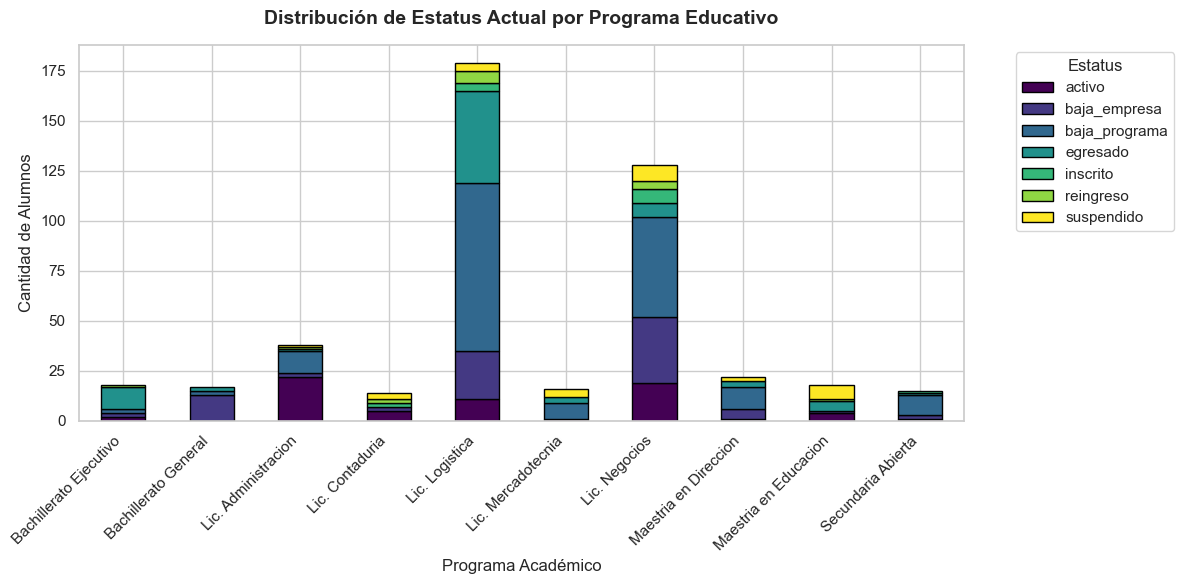

In [21]:
# Esto es el simple estilo de graficos como el fondo y el tamaño del lienzo 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Grafica 1: Barras apiladas (estatus por programa)
#Aqui indicamos que tome la tabla de la distribucion de estatus actual por programa y le decimos que se grafique en barras
dist_groupby.plot(kind="bar", stacked=True, colormap="viridis", edgecolor="black")
#aqui son los textos y los estilos de los textos
plt.title("Distribución de Estatus Actual por Programa Educativo", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Programa Académico", fontsize=12)
plt.ylabel("Cantidad de Alumnos", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Estatus", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("estatus_por_programa.png", dpi=300)
plt.show()

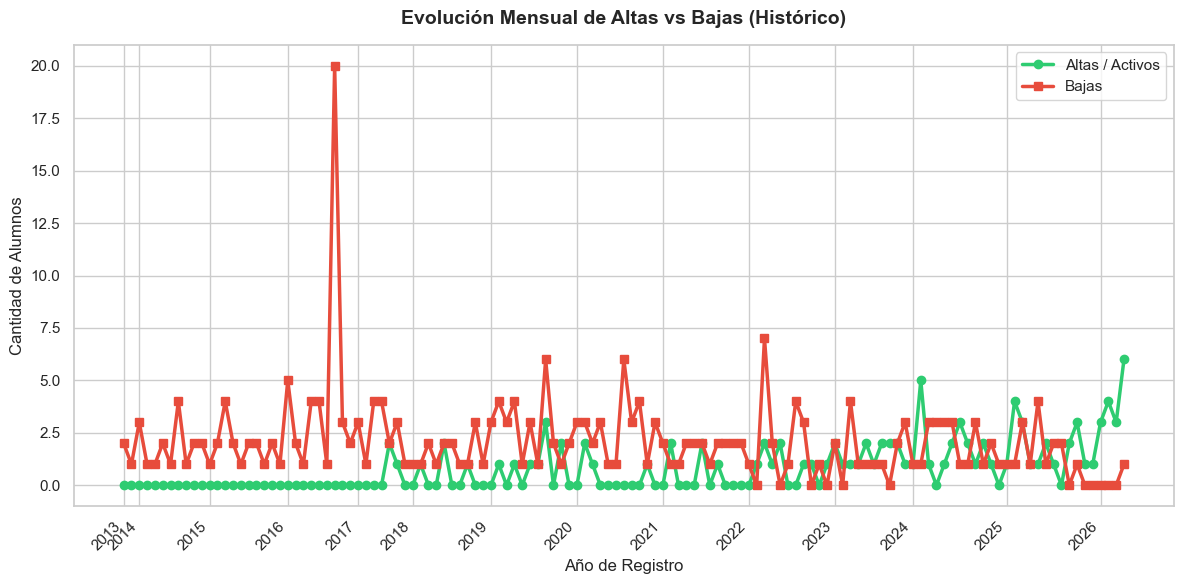

In [24]:
# Grafica 2: Línea (altas y bajas por mes)
# Copiamos la tabla que ya tenemos  y pasamos el indice a texto
evolucion_grafica = evolucion_mensual.copy()
evolucion_grafica.index = evolucion_grafica.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(evolucion_grafica.index, evolucion_grafica["altas_activos"], marker="o", linewidth=2.5, color="#2ecc71", label="Altas / Activos")
plt.plot(evolucion_grafica.index, evolucion_grafica["bajas"], marker="s", linewidth=2.5, color="#e74c3c", label="Bajas")
#estilo de los textos 
plt.title("Evolución Mensual de Altas vs Bajas (Histórico)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Año de Registro", fontsize=12)
plt.ylabel("Cantidad de Alumnos", fontsize=12)

# filtramos las etiquetas del eje X para mostrar solo los años 
anos_detectados = pd.to_datetime(evolucion_grafica.index).year
posiciones_ticks = []
etiquetas_ticks = []

# Buscamos el indice donde empieza cada año para poner la marca de tiempo ahi
for ano in sorted(list(set(anos_detectados))):
    idx = list(anos_detectados).index(ano)
    posiciones_ticks.append(idx)
    etiquetas_ticks.append(str(ano))
    
plt.xticks(posiciones_ticks, etiquetas_ticks, rotation=45, ha="right")

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("altas_vs_bajas_mensual.png", dpi=300)
plt.show()